# Estimating Mutual Information with scConcept

This tutorial demonstrates how to estimate mutual information between a gene panel and the full transcriptome using scConcept.


In [1]:
import os
from pathlib import Path

import numpy as np
import scanpy as sc

from concept import scConcept

/ictstr01/groups/ml01/workspace/mojtaba.bahrami/projects/scConcept/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The directory where the pre-trained model and example dataset will be stored:

In [2]:
cache_dir = Path("./cache/")
os.makedirs(cache_dir, exist_ok=True)

Download the same sample dataset used in the embedding extraction tutorial:

In [3]:
filename = cache_dir / "multiome_gex_processed_training.h5ad"
url = "https://openproblems-bio.s3.amazonaws.com/public/explore/multiome/multiome_gex_processed_training.h5ad"

if not os.path.exists(filename):
    import urllib.request

    print(f"Downloading {filename} ...")
    urllib.request.urlretrieve(url, filename)
else:
    print(f"{filename} already exists, skipping download.")

adata = sc.read(filename)
print(adata)

cache/multiome_gex_processed_training.h5ad already exists, skipping download.
AnnData object with n_obs × n_vars = 42492 × 13431
    obs: 'pct_counts_mt', 'n_counts', 'n_genes', 'size_factors', 'phase', 'cell_type', 'pseudotime_order_GEX', 'batch', 'pseudotime_order_ATAC', 'is_train'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'dataset_id', 'organism'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'


Load a pre-trained scConcept model:

In [4]:
concept = scConcept(cache_dir=cache_dir)
concept.load_config_and_model(model_name="corpus40M-model30M")

INFO: Loading config and model from HuggingFace Hub (theislab/scConcept/corpus40M-model30M)...
INFO: Checkpoint already exists at cache/corpus40M-model30M/model.ckpt
INFO: Downloading gene_mappings directory from HuggingFace Hub (theislab/scConcept/corpus40M-model30M/gene_mappings/)...
INFO: Gene mappings saved to cache/corpus40M-model30M/gene_mappings
INFO: Config already exists at cache/corpus40M-model30M/config.yaml
INFO: Downloading panels directory from HuggingFace Hub (theislab/scConcept/corpus40M-model30M/panels/)...
INFO: Panels directory saved to cache/corpus40M-model30M/panels
INFO: No pretrained vocabulary found in HuggingFace Hub (theislab/scConcept/corpus40M-model30M/pretrained_vocabulary/)
INFO: Model loaded successfully on cuda


Subsample cells for a faster example, then define a panel. Here we use the first 200 genes from `adata.var['gene_ids']` only as a simple example. In practice, replace `panel_gene_ids` with the gene IDs from your panel.

In [5]:
estimate_size = min(2048, adata.n_obs)
rng = np.random.default_rng(seed=42)
random_indices = rng.choice(adata.n_obs, estimate_size, replace=False)
adata_subset = adata[random_indices].copy()

panel_gene_ids = adata_subset.var["gene_ids"].astype(str).to_numpy()[:200]
panel_mask = adata_subset.var["gene_ids"].astype(str).isin(panel_gene_ids).to_numpy()
adata_panel = adata_subset[:, panel_mask].copy()

print(f"Cells used: {adata_subset.n_obs}")
print(f"Full transcriptome genes: {adata_subset.n_vars}")
print(f"Panel genes used: {adata_panel.n_vars}")

Cells used: 2048
Full transcriptome genes: 13431
Panel genes used: 200


Extract embeddings for the full transcriptome and for the panel, then estimate mutual information between them:

In [6]:
embedding_kwargs = {
    "batch_size": 64,
    "gene_id_column": "gene_ids",
    "return_type": "torch",
}

cell_embs_full = concept.extract_embeddings(adata_subset, **embedding_kwargs)["cls_cell_emb"]
cell_embs_panel = concept.extract_embeddings(adata_panel, **embedding_kwargs)["cls_cell_emb"]

mutual_info = concept.estimate_mutual_information(cell_embs_full, cell_embs_panel)
print(f"Estimated mutual information: {mutual_info:.4f}")

INFO: Extracting embeddings from AnnData with shape (2048, 13431)
INFO: Parameters: max_tokens=1000, batch_size=64, gene_sampling_strategy=top-nonzero
INFO: Inferred species 'hsapiens' from gene overlap.
Generating embeddings: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:13<00:00,  2.35it/s]
INFO: Extracted embeddings with shape: cls=torch.Size([2048, 512])
INFO: Extracting embeddings from AnnData with shape (2048, 200)
INFO: Parameters: max_tokens=1000, batch_size=64, gene_sampling_strategy=top-nonzero
INFO: Inferred species 'hsapiens' from gene overlap.
Generating embeddings: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:00<00:00, 75.21it/s]
INFO: Extracted embeddings with shape: cls=torch.Size([2048, 512])


Estimated mutual information: 0.7974


## Larger Panels Increase Mutual Information

This simple example uses nested panels of increasing size and compares each one to the same full-transcriptome embedding.

INFO: Extracting embeddings from AnnData with shape (2048, 100)
INFO: Parameters: max_tokens=1000, batch_size=64, gene_sampling_strategy=top-nonzero
INFO: Inferred species 'hsapiens' from gene overlap.
Generating embeddings: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:00<00:00, 52.47it/s]
INFO: Extracted embeddings with shape: cls=torch.Size([2048, 512])
INFO: Extracting embeddings from AnnData with shape (2048, 200)
INFO: Parameters: max_tokens=1000, batch_size=64, gene_sampling_strategy=top-nonzero
INFO: Inferred species 'hsapiens' from gene overlap.
Generating embeddings: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:00<00:00, 64.81it/s]
INFO: Extracted embeddings with shape: cls=torch.Size([2048, 512])
INFO: Extracting embeddings from A

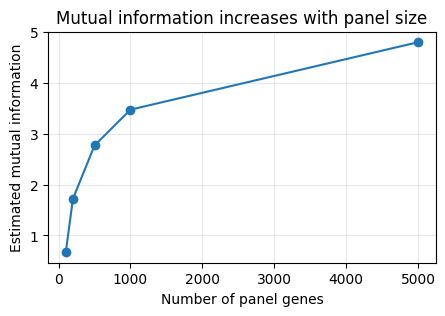

In [7]:
import matplotlib.pyplot as plt

mean_expression = np.asarray(adata_subset.X.mean(axis=0)).ravel()
gene_order = adata_subset.var.iloc[np.argsort(mean_expression)[::-1]]["gene_ids"].astype(str).to_numpy()
panel_sizes = [100, 200, 500, 1000, 5000]
panel_sizes = [size for size in panel_sizes if size <= len(gene_order)]

mutual_infos = []
for panel_size in panel_sizes:
    panel_gene_ids = gene_order[:panel_size]
    panel_mask = adata_subset.var["gene_ids"].astype(str).isin(panel_gene_ids).to_numpy()
    adata_panel = adata_subset[:, panel_mask].copy()
    cell_embs_panel = concept.extract_embeddings(adata_panel, **embedding_kwargs)["cls_cell_emb"]
    mutual_info = concept.estimate_mutual_information(cell_embs_full, cell_embs_panel)
    mutual_infos.append(mutual_info)

plt.figure(figsize=(5, 3))
plt.plot(panel_sizes, mutual_infos, marker="o")
plt.xlabel("Number of panel genes")
plt.ylabel("Estimated mutual information")
plt.title("Mutual information increases with panel size")
plt.grid(True, alpha=0.3)
plt.show()